# 🎮 Dự Án Game Churn Prediction & Player Analytics
## Notebook 01: Exploratory Data Analysis (EDA) & Reusable Analytics Framework

> **Mục tiêu:**
> 1. Khám phá tập dữ liệu hành vi người chơi game (`online_gaming_behavior_dataset.csv`).
> 2. Đánh giá chất lượng dữ liệu (Data Hygiene: Missing values, Duplicates, Data Types).
> 3. Phân tích các yếu tố hành vi tác động đến việc người chơi rời bỏ game (**Churn** / **Engagement Level**).
> 4. Xây dựng bộ hàm phân tích mô-đun hóa có thể tái sử dụng cho các dự án phân tích dữ liệu dạng bảng khác.

In [1]:
# 1. Khai báo các thư viện cần thiết
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Cấu hình phong cách biểu đồ
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

---
## 1. Tải dữ liệu & Kiểm tra chất lượng (Data Hygiene Framework)
Phần này cung cấp hàm `inspect_data()` tự động tóm tắt kích thước, kiểu dữ liệu, tỷ lệ khuyết thiếu và tự động phân loại cột số / cột phân loại. Hàm này có thể tái sử dụng cho bất kỳ tập dữ liệu dạng bảng nào.

In [2]:
# 2. Đọc tập dữ liệu từ data/raw/
DATA_PATH = Path('../data/raw/online_gaming_behavior_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/online_gaming_behavior_dataset.csv')

df = pd.read_csv(DATA_PATH)
print(f"✅ Đã tải dữ liệu thành công: {df.shape[0]:,} dòng, {df.shape[1]} cột.")
df.head()

✅ Đã tải dữ liệu thành công: 40,034 dòng, 13 cột.


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.526,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.224,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.532,0,Medium,2,131,95,37,Medium


In [3]:
# 3. Khung kiểm tra chất lượng dữ liệu tái sử dụng (Reusable Data Hygiene Function)
def inspect_data(data: pd.DataFrame, id_cols: list = None) -> tuple[list, list]:
    """Tự động kiểm tra chất lượng dữ liệu và phân loại biến số / biến phân loại.
    Tái sử dụng được cho mọi dự án Tabular Data.
    """
    id_cols = id_cols or []
    print('=' * 60)
    print('📋 BÁO CÁO CHẤT LƯỢNG DỮ LIỆU (DATA HYGIENE REPORT)')
    print('=' * 60)
    print(f'• Số lượng bản ghi (Rows) : {data.shape[0]:,}')
    print(f'• Số lượng thuộc tính (Cols): {data.shape[1]}')
    print(f'• Số dòng trùng lặp (Duplicates): {data.duplicated().sum()}')
    
    # Kiểm tra missing values
    missing = data.isnull().sum()
    missing_pct = (missing / len(data)) * 100
    missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Pct (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing_Count'] > 0]
    
    if len(missing_df) == 0:
        print('• Giá trị khuyết thiếu (Missing Values): 0 (Dữ liệu hoàn toàn đầy đủ! ✨)')
    else:
        print('• Các cột có giá trị khuyết thiếu:')
        print(missing_df)
        
    print('-' * 60)
    # Tự động tách cột số và cột phân loại
    num_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c not in id_cols]
    cat_cols = [c for c in data.select_dtypes(exclude=[np.number]).columns if c not in id_cols]
    
    print(f'📊 Cột số ({len(num_cols)}): {num_cols}')
    print(f'🏷️ Cột phân loại ({len(cat_cols)}): {cat_cols}')
    print('=' * 60)
    return num_cols, cat_cols

num_cols, cat_cols = inspect_data(df, id_cols=['PlayerID'])

📋 BÁO CÁO CHẤT LƯỢNG DỮ LIỆU (DATA HYGIENE REPORT)
• Số lượng bản ghi (Rows) : 40,034
• Số lượng thuộc tính (Cols): 13
• Số dòng trùng lặp (Duplicates): 0
• Giá trị khuyết thiếu (Missing Values): 0 (Dữ liệu hoàn toàn đầy đủ! ✨)
------------------------------------------------------------
📊 Cột số (7): ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']
🏷️ Cột phân loại (5): ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']


In [4]:
# 4. Thống kê mô tả 5 số (Five-number summary) cho các biến số
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,40034.000,31.993,10.043,15.000,23.000,32.000,41.000,49.000
PlayTimeHours,40034.000,12.024,6.915,0.000,6.068,12.008,17.964,24.000
InGamePurchases,40034.000,0.201,0.401,0.000,0.000,0.000,0.000,1.000
SessionsPerWeek,40034.000,9.472,5.764,0.000,4.000,9.000,14.000,19.000
AvgSessionDurationMinutes,40034.000,94.792,49.011,10.000,52.000,95.000,137.000,179.000
PlayerLevel,40034.000,49.656,28.588,1.000,25.000,49.000,74.000,99.000
AchievementsUnlocked,40034.000,24.526,14.431,0.000,12.000,25.000,37.000,49.000


---
## 2. Phân tích Biến Mục tiêu: Engagement Level & Churn Definition
Trong bài toán Game Churn:
- Cột `EngagementLevel` có 3 mức: `High`, `Medium`, `Low`.
- Nhóm **`Low`** là nhóm người chơi có nguy cơ rời bỏ game cao nhất (hoặc đã bỏ game).
- Để phục vụ bài toán phân loại nhị phân (Binary Classification) dự đoán Churn, ta tạo thêm biến nhãn `IsChurn`:
  - `IsChurn = 1` nếu `EngagementLevel == 'Low'` (Người chơi rời bỏ / Nguy cơ cao).
  - `IsChurn = 0` nếu `EngagementLevel in ['Medium', 'High']` (Người chơi gắn bó).

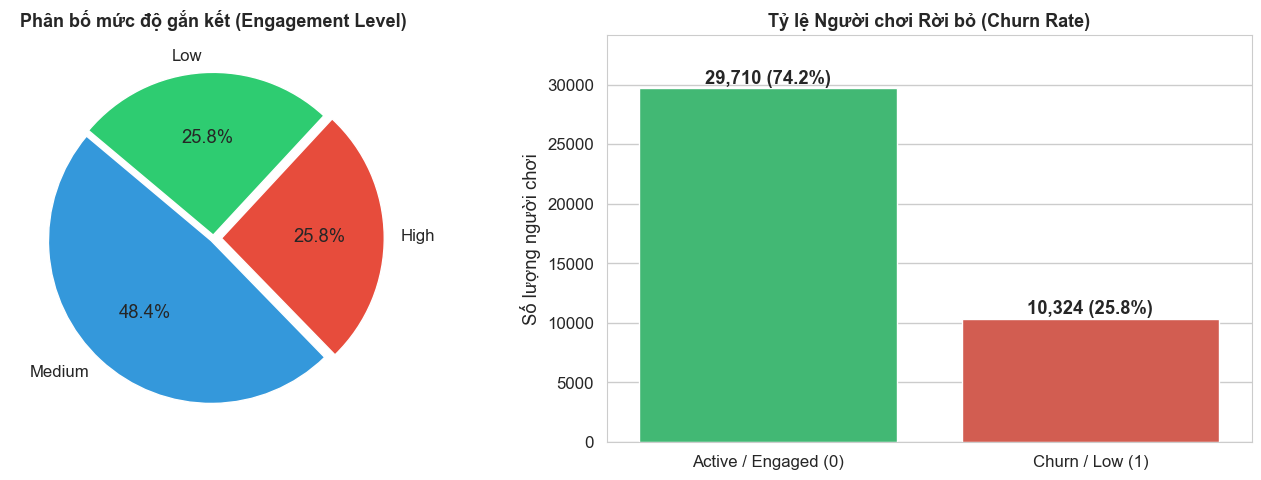

👉 Tỷ lệ Churn tổng thể của game: 25.79%


In [5]:
# 5. Khởi tạo nhãn Churn và phân tích tỷ lệ
df['IsChurn'] = (df['EngagementLevel'] == 'Low').astype(int)

engagement_counts = df['EngagementLevel'].value_counts()
churn_counts = df['IsChurn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Engagement Level Pie chart
axes[0].pie(
    engagement_counts, 
    labels=engagement_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#3498db', '#e74c3c', '#2ecc71'],
    explode=(0.02, 0.05, 0.02)
)
axes[0].set_title('Phân bố mức độ gắn kết (Engagement Level)', fontsize=13, fontweight='bold')

# Biểu đồ 2: Churn Count Bar chart
sns.barplot(x=['Active / Engaged (0)', 'Churn / Low (1)'], y=churn_counts.values, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 400, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Tỷ lệ Người chơi Rời bỏ (Churn Rate)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số lượng người chơi')
axes[1].set_ylim(0, churn_counts.max() * 1.15)

plt.tight_layout()
plt.show()

print(f"👉 Tỷ lệ Churn tổng thể của game: {df['IsChurn'].mean() * 100:.2f}%")

---
## 3. Phân tích Đơn biến (Univariate Analysis - Khung tái sử dụng)
Khung vẽ tự động phân bố (Histogram + KDE) cho tất cả các biến số nhằm phát hiện hình dáng phân bố (chuẩn hay lệch) và khoảng giá trị.

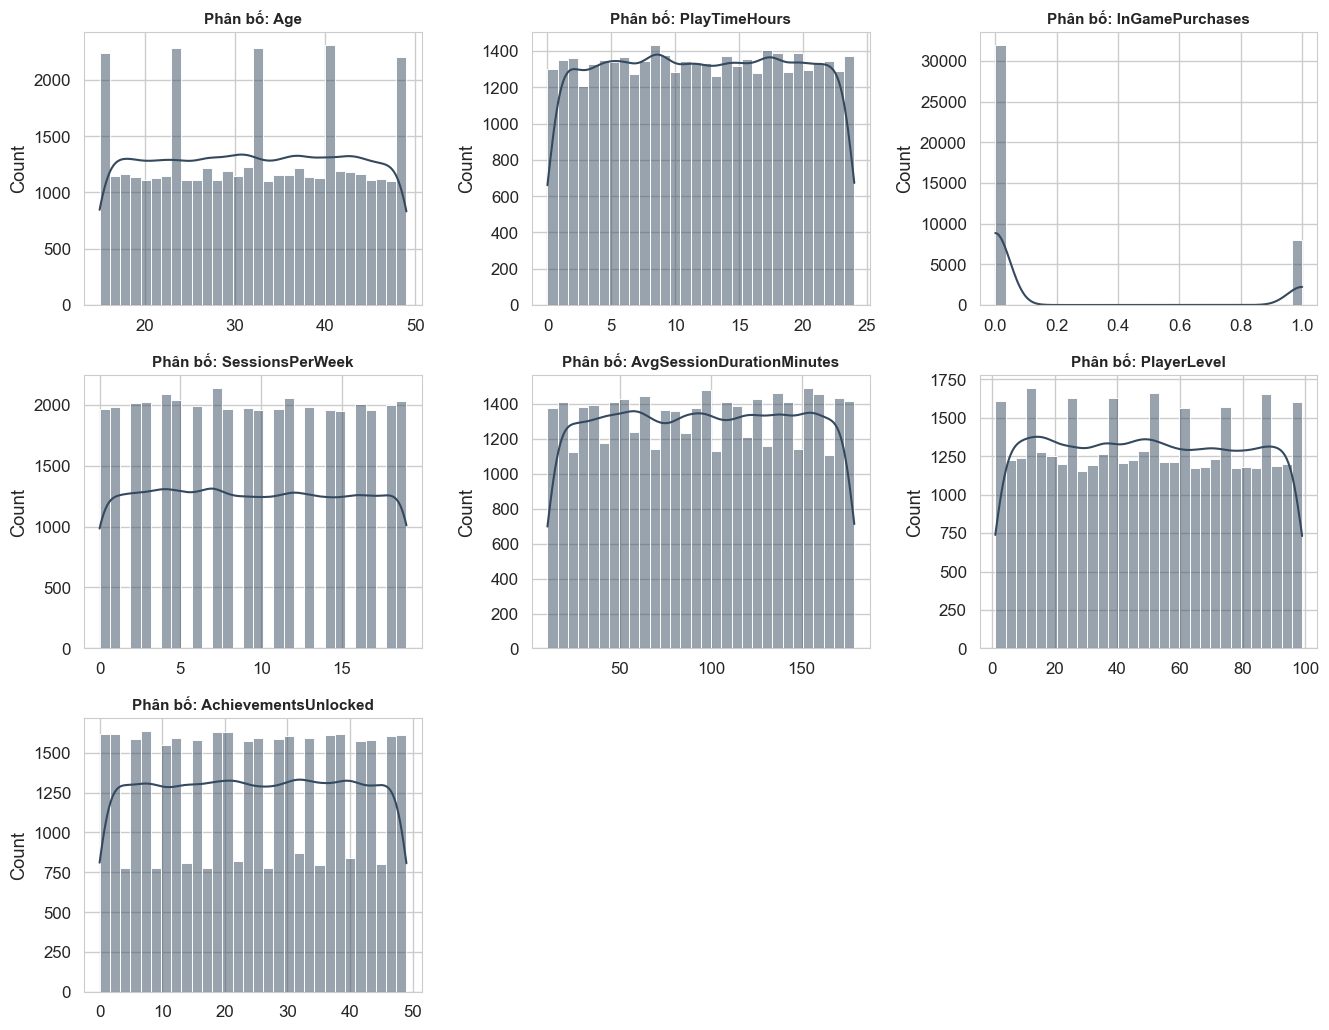

In [6]:
# 6. Hàm trực quan hóa phân bố biến số tự động (Tái sử dụng cho mọi dự án)
def plot_numerical_distributions(data: pd.DataFrame, columns: list, ncols: int = 3):
    """Vẽ Histogram kèm đường KDE cho danh sách cột số."""
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=True, ax=axes[i], color='#34495e', edgecolor='white', bins=30)
        axes[i].set_title(f'Phân bố: {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_numerical_distributions(df, [c for c in num_cols if c != 'IsChurn'])

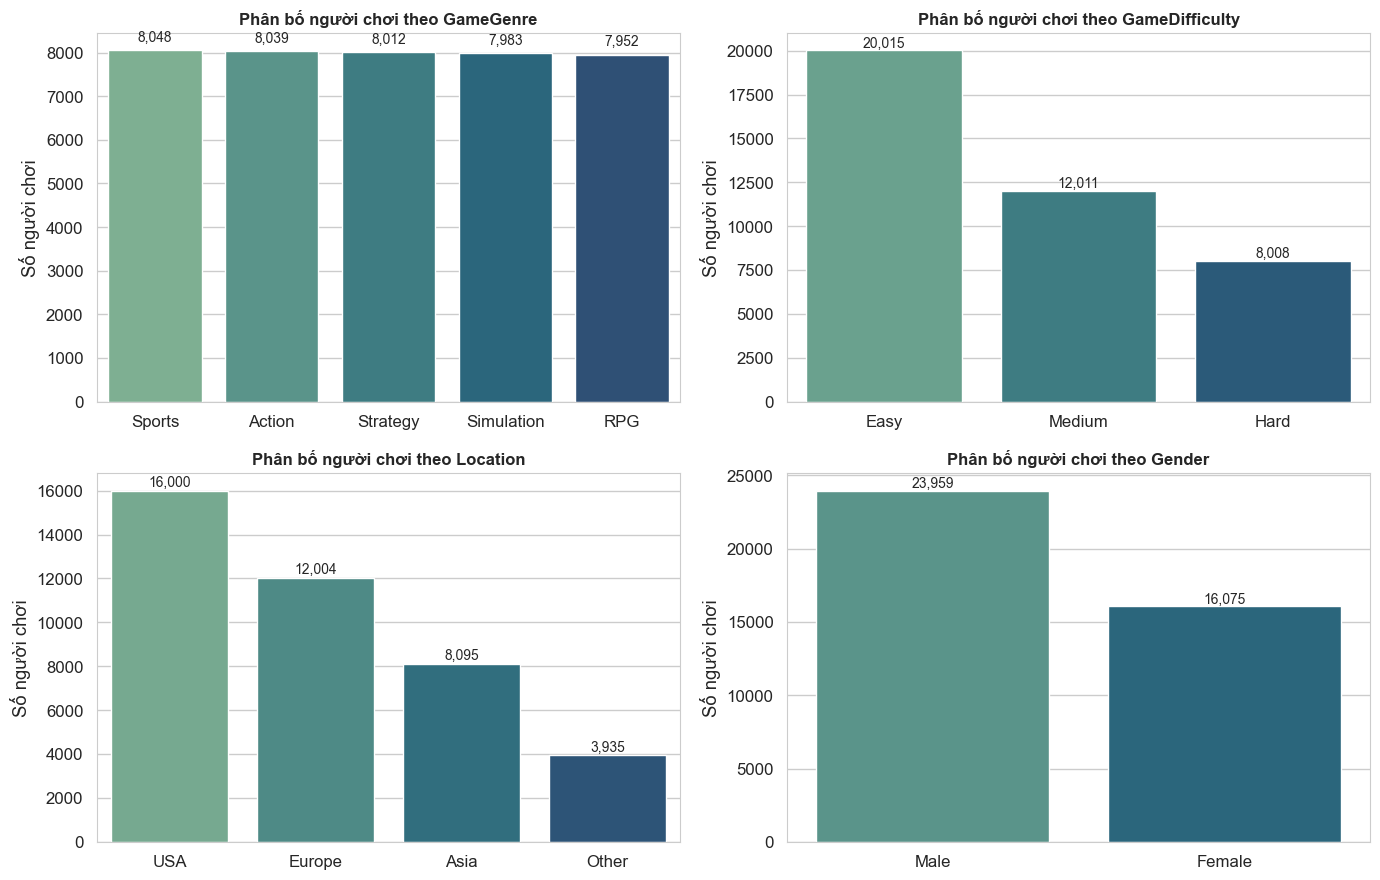

In [7]:
# 7. Phân tích các biến phân loại (Categorical Features)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(['GameGenre', 'GameDifficulty', 'Location', 'Gender']):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='crest')
    axes[i].set_title(f'Phân bố người chơi theo {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Số người chơi')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}', 
                         (p.get_x() + p.get_width() / 2., p.get_height() + 200), 
                         ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 4. Phân tích Hai biến & Hành vi Game thủ (Bivariate Analysis: Features vs Churn)
Tìm kiếm các mẫu hình khác biệt giữa người chơi gắn bó và người chơi rời bỏ game.

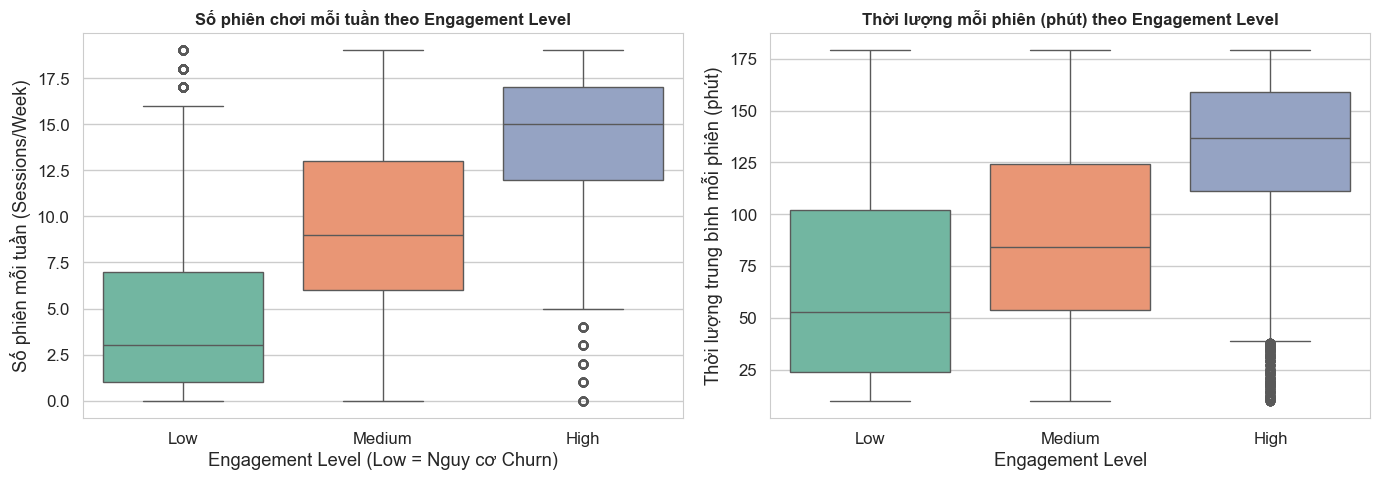

In [8]:
# 8. Tác động của Thói quen chơi game (SessionsPerWeek & Duration) đến Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='EngagementLevel', y='SessionsPerWeek', order=['Low', 'Medium', 'High'], palette='Set2', ax=axes[0])
axes[0].set_title('Số phiên chơi mỗi tuần theo Engagement Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Engagement Level (Low = Nguy cơ Churn)')
axes[0].set_ylabel('Số phiên mỗi tuần (Sessions/Week)')

sns.boxplot(data=df, x='EngagementLevel', y='AvgSessionDurationMinutes', order=['Low', 'Medium', 'High'], palette='Set2', ax=axes[1])
axes[1].set_title('Thời lượng mỗi phiên (phút) theo Engagement Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Engagement Level')
axes[1].set_ylabel('Thời lượng trung bình mỗi phiên (phút)')

plt.tight_layout()
plt.show()

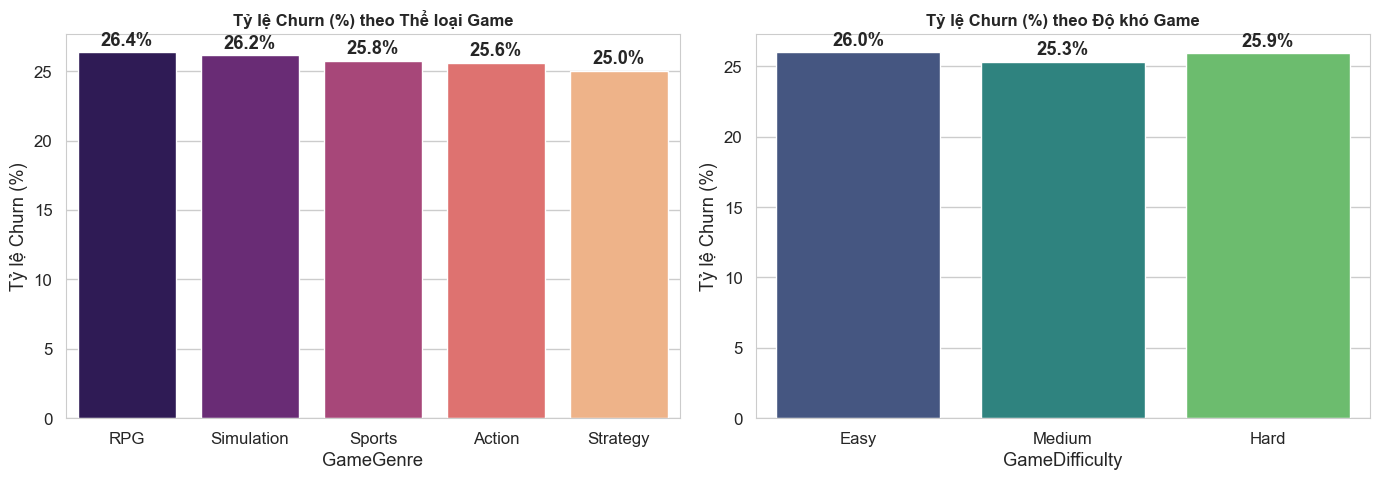

In [9]:
# 9. Tỷ lệ Churn theo Thể loại Game (GameGenre) và Độ khó (GameDifficulty)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate theo Genre
genre_churn = df.groupby('GameGenre')['IsChurn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=genre_churn.index, y=genre_churn.values, ax=axes[0], palette='magma')
axes[0].set_title('Tỷ lệ Churn (%) theo Thể loại Game', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Churn (%)')
for i, v in enumerate(genre_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn rate theo Difficulty
diff_order = ['Easy', 'Medium', 'Hard']
diff_churn = df.groupby('GameDifficulty')['IsChurn'].mean().reindex(diff_order) * 100
sns.barplot(x=diff_churn.index, y=diff_churn.values, ax=axes[1], palette='viridis')
axes[1].set_title('Tỷ lệ Churn (%) theo Độ khó Game', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ Churn (%)')
for i, v in enumerate(diff_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Thống kê Churn Rate theo hành vi Nạp tiền:
                 count  mean  ChurnRate(%)
InGamePurchases                           
0                31993 0.259        25.903
1                 8041 0.253        25.333


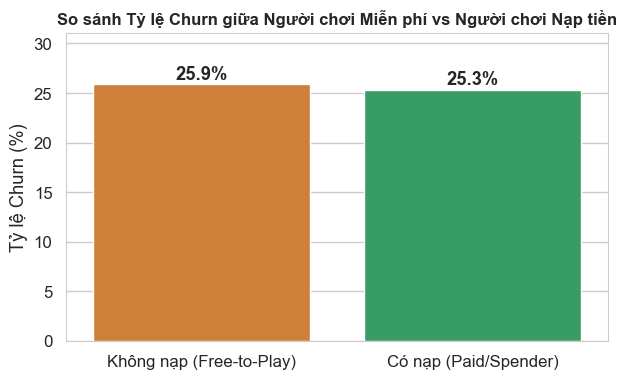

In [10]:
# 10. Tác động của Hành vi Nạp tiền (InGamePurchases) đến việc giữ chân
purchase_churn = df.groupby('InGamePurchases')['IsChurn'].agg(['count', 'mean'])
purchase_churn['ChurnRate(%)'] = purchase_churn['mean'] * 100

print('Thống kê Churn Rate theo hành vi Nạp tiền:')
print(purchase_churn)

plt.figure(figsize=(7, 4))
sns.barplot(x=['Không nạp (Free-to-Play)', 'Có nạp (Paid/Spender)'], y=purchase_churn['ChurnRate(%)'], palette=['#e67e22', '#27ae60'])
plt.title('So sánh Tỷ lệ Churn giữa Người chơi Miễn phí vs Người chơi Nạp tiền', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ Churn (%)')
for i, v in enumerate(purchase_churn['ChurnRate(%)']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.ylim(0, purchase_churn['ChurnRate(%)'].max() * 1.2)
plt.show()

---
## 5. Phân tích Tương quan (Correlation Analysis - Khung tái sử dụng)
Ma trận tương quan Pearson giúp nhận diện các biến có liên kết tuyến tính mạnh nhất với `IsChurn`.

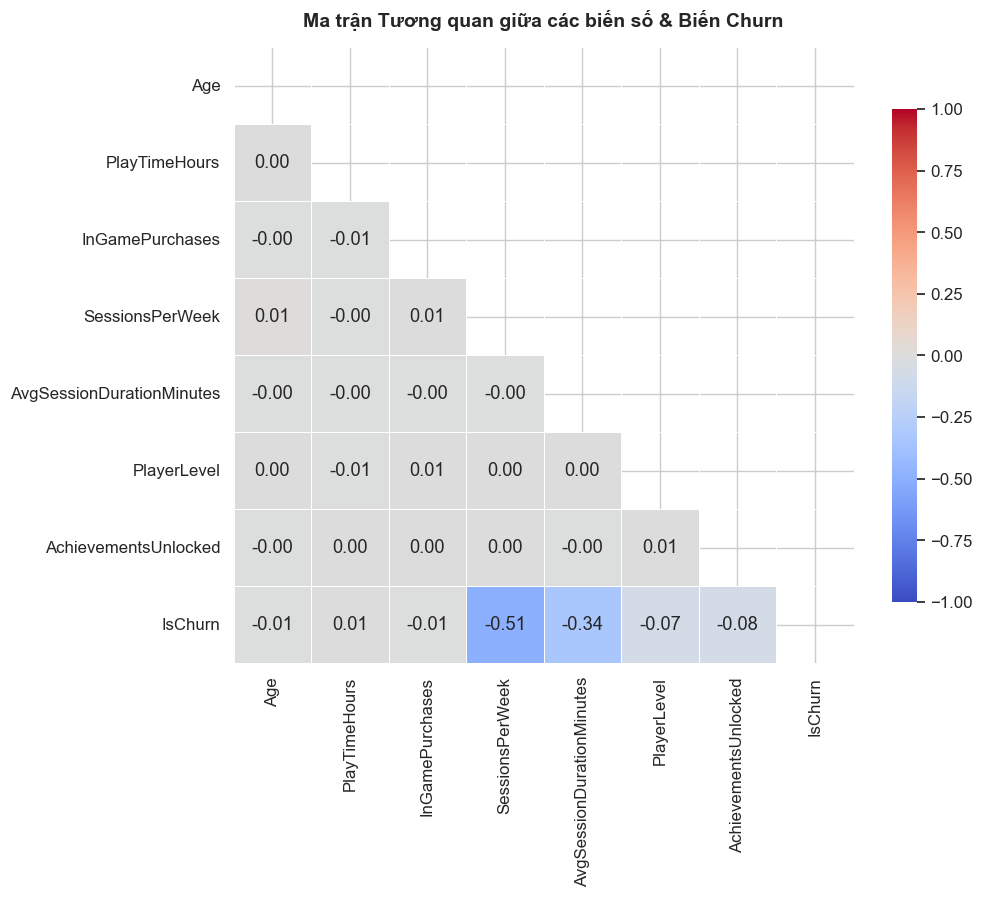

Top biến tương quan mạnh nhất với việc Churn:
SessionsPerWeek             -0.505
AvgSessionDurationMinutes   -0.336
AchievementsUnlocked        -0.076
PlayerLevel                 -0.073
PlayTimeHours                0.007
Age                         -0.006
InGamePurchases             -0.005
Name: IsChurn, dtype: float64


In [11]:
# 11. Ma trận tương quan giữa các biến số
corr_cols = [c for c in num_cols if c != 'PlayerID'] + ['IsChurn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận Tương quan giữa các biến số & Biến Churn', fontsize=14, fontweight='bold', pad=15)
plt.show()

# Top thuộc tính tương quan cao nhất với Churn
print('Top biến tương quan mạnh nhất với việc Churn:')
print(corr_matrix['IsChurn'].drop('IsChurn').sort_values(key=abs, ascending=False))

---
## 6. Phân đoạn Người chơi (Player Segmentation / Persona)
Trực quan hóa sự phân bố theo `PlayTimeHours` và `SessionsPerWeek` để thấy rõ ranh giới giữa nhóm gắn kết và nhóm có nguy cơ rời bỏ.

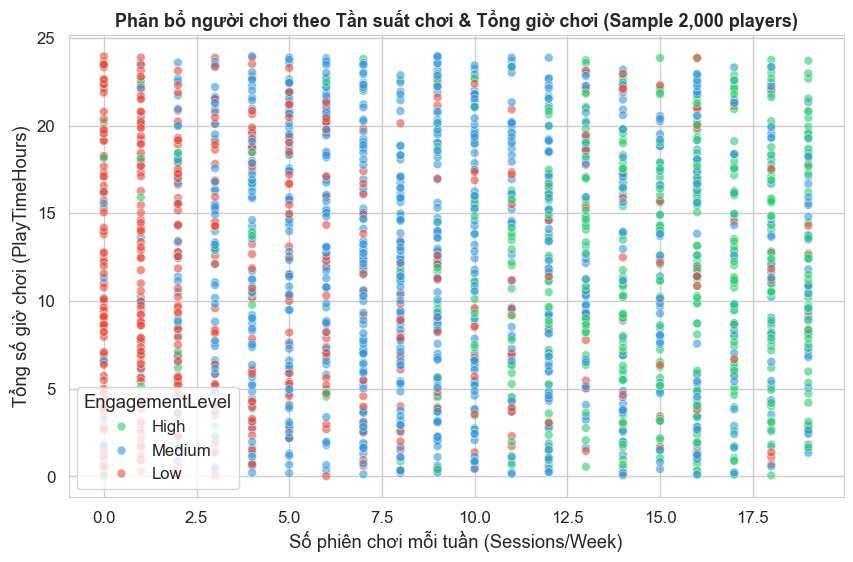

In [12]:
# 12. Trực quan hóa phân cụm người chơi theo PlayTimeHours vs SessionsPerWeek
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='SessionsPerWeek', 
    y='PlayTimeHours', 
    hue='EngagementLevel', 
    hue_order=['High', 'Medium', 'Low'],
    palette={'High': '#2ecc71', 'Medium': '#3498db', 'Low': '#e74c3c'},
    alpha=0.6,
    s=40
)
plt.title('Phân bổ người chơi theo Tần suất chơi & Tổng giờ chơi (Sample 2,000 players)', fontsize=13, fontweight='bold')
plt.xlabel('Số phiên chơi mỗi tuần (Sessions/Week)')
plt.ylabel('Tổng số giờ chơi (PlayTimeHours)')
plt.show()

---
## 7. Tổng kết Key Insights & Đề xuất cho Feature Engineering (Notebook 02)

### 📌 Các phát hiện quan trọng từ EDA:
1. **Chất lượng dữ liệu:** Tập dữ liệu gồm 40,034 người chơi, không có missing values hay duplicates.
2. **Tỷ lệ Churn cơ sở (Base Churn Rate):** Khoảng 25.8% người chơi thuộc nhóm nguy cơ rời bỏ cao (`EngagementLevel == 'Low'`).
3. **Các yếu tố dẫn dắt chính (Key Drivers):**
   - **Tần suất chơi (`SessionsPerWeek`) & Thời lượng (`AvgSessionDurationMinutes`):** Người chơi churn có số phiên và thời gian chơi thấp rõ rệt.
   - **Cấp độ (`PlayerLevel`) & Thành tích (`AchievementsUnlocked`):** Càng lên level cao và mở nhiều achievement, tỷ lệ gắn kết càng cao.
   - **Hành vi nạp tiền (`InGamePurchases`):** Nhóm nạp tiền có xu hướng gắn bó hơn nhóm free-to-play.

### 🎯 Hướng phát triển cho Notebook 02 (`02_FeatureEngineering.ipynb`):
1. **Tạo biến tương tác (Interaction Features):**
   - `TotalWeeklyMinutes = SessionsPerWeek * AvgSessionDurationMinutes` (Tổng thời gian chơi mỗi tuần).
   - `PlayTimePerLevel = PlayTimeHours / (PlayerLevel + 1)` (Tốc độ cày cấp).
   - `AchievementsPerLevel = AchievementsUnlocked / (PlayerLevel + 1)`.
2. **Mã hóa biến phân loại (Encoding):** One-Hot Encoding cho `GameGenre`, `GameDifficulty`, `Location`, `Gender`.
3. **Chuẩn hóa biến số (Scaling):** StandardScaler / RobustScaler cho các biến thời gian và phiên chơi.
4. **Lưu dữ liệu:** Xuất file đã sẵn sàng cho mô hình hóa ra `data/processed/gaming_features.csv`.